# FairDerm: Second Seed Run (Seed 123)

This notebook runs all experiments with seed=123 to complement the existing seed=42 results.

**Purpose:** Enable statistical analysis with mean ± std across 2 seeds.


## 1. Setup

In [1]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install timm --quiet

In [3]:
# Add fairderm package to path (if running from Colab)
import sys
sys.path.insert(0, '/content/drive/MyDrive/thesis/code')

# Import standard libraries
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import custom fairderm modules
from fairderm import (
    SkinLesionDataset,
    create_model,
    SkinToneAdaptiveSampler,
    get_class_weights,
    get_train_transforms,
    get_eval_transforms,
    run_experiment,
    save_experiment_results,
)
from fairderm.configs import (
    get_baseline_config,
    get_mixup_config,
    get_reweighted_config,
    get_focal_config,
    get_proposed_config,
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
import os

# =============================================
# CONFIGURATION - SEED 123
# =============================================
SEED = 123  # NEW SEED (different from original 42)

PROJECT_DIR = '/content/drive/MyDrive/thesis'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

CSV_PATH = os.path.join(DATA_DIR, 'fitzpatrick17k_processed.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Running experiments with SEED = {SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Running experiments with SEED = 123
Data directory: /content/drive/MyDrive/thesis/data
Results directory: /content/drive/MyDrive/thesis/results


## 2. Load and Prepare Data

**Important:** We use the SAME random_state=42 for train/val split to ensure identical data splits across seeds. Only the model training uses the new seed.

In [5]:
# Load the processed CSV
df = pd.read_csv(CSV_PATH)

# Show dataset summary
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"\nTotal samples: {len(df)}")
print("\nSkin tone group distribution:")
print(df['tone_group'].value_counts())

DATASET SUMMARY

Total samples: 4491

Skin tone group distribution:
tone_group
Light      2308
Medium     1599
Dark        409
Unknown     175
Name: count, dtype: int64


In [6]:
# Create stratified train/val split
# IMPORTANT: Use random_state=42 (same as original) to get IDENTICAL splits
# Only the model training will use the new seed (123)
df['stratify_key'] = df['label'].astype(str) + '_' + df['tone_group']

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,  # KEEP AS 42 for identical splits!
    stratify=df['stratify_key']
)

train_df = train_df.drop('stratify_key', axis=1).reset_index(drop=True)
val_df = val_df.drop('stratify_key', axis=1).reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
print("\n(Using same train/val split as seed=42 run)")

Train set: 3592 samples
Val set: 899 samples

(Using same train/val split as seed=42 run)


In [7]:
# Create datasets with transforms
train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

train_dataset = SkinLesionDataset(train_df, transform=train_transform, return_group=True)
val_dataset = SkinLesionDataset(val_df, transform=eval_transform, return_group=True)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")

Train dataset: 3592 samples
Val dataset: 899 samples


In [8]:
# Compute class weights for reweighted baseline
class_weights = get_class_weights(train_df, label_col='label_num')
print(f"Class weights: {class_weights}")

Class weights: tensor([1.0073, 0.9928])


In [9]:
# Store all results
all_results = {}

## 3. Run All Experiments with Seed 123

### 3.1 Baseline

In [10]:
config = get_baseline_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'baseline_seed{SEED}'] = results

# Save model
save_experiment_results(results, f'baseline_seed{SEED}', RESULTS_DIR)


Experiment: Baseline (seed=123)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]


Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [05:33<00:00, 11.50s/it]

...

Train Loss: 0.0630 | Train Acc: 0.9791
Val Loss: 0.6571 | Val Acc: 0.8420

Epoch 14/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.78it/s]


Train Loss: 0.0413 | Train Acc: 0.9830
Val Loss: 0.6755 | Val Acc: 0.8432

Early stopping at epoch 14

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:07<00:00,  3.63it/s]



Baseline Results:
  Accuracy: 0.8365
  Balanced Accuracy: 0.8366
  ROC-AUC: 0.9200

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8285 (n=462)
  Medium: 0.8013 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.0967

Per-Group False Positive Rates:
  Light: 0.1614
  Medium: 0.1124
  Dark: 0.1220
  -> Equalized Odds Gap: 0.0967

Per-Group F1 Scores:
  Light: 0.8372
  Medium: 0.8316
  Dark: 0.7895
  -> Inter-group F1 Gap: 0.0477

Results saved to /content/drive/MyDrive/thesis/results/baseline_seed123


### 3.2 Mixup

In [11]:
config = get_mixup_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'mixup_seed{SEED}'] = results

save_experiment_results(results, f'mixup_seed{SEED}', RESULTS_DIR)


Experiment: Mixup (seed=123)

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  7.23it/s]

Train Loss: 0.6188 | Train Acc: 0.6609
Val Loss: 0.5082 | Val Acc: 0.7642

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.04it/s]

Train Loss: 0.5301 | Train Acc: 0.7374
Val Loss: 0.4522 | Val Acc: 0.8065

Epoch 3/50


...

Train Loss: 0.2747 | Train Acc: 0.9095
Val Loss: 0.3787 | Val Acc: 0.8509

Epoch 18/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.23it/s]


Train Loss: 0.3100 | Train Acc: 0.8848
Val Loss: 0.3784 | Val Acc: 0.8454

Early stopping at epoch 18

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.61it/s]



Mixup Results:
  Accuracy: 0.8465
  Balanced Accuracy: 0.8466
  ROC-AUC: 0.9182

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8075 (n=462)
  Medium: 0.8411 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.1094

Per-Group False Positive Rates:
  Light: 0.1570
  Medium: 0.0828
  Dark: 0.0976
  -> Equalized Odds Gap: 0.1094

Per-Group F1 Scores:
  Light: 0.8266
  Medium: 0.8699
  Dark: 0.8000
  -> Inter-group F1 Gap: 0.0699

Results saved to /content/drive/MyDrive/thesis/results/mixup_seed123


### 3.3 Reweighted

In [12]:
config = get_reweighted_config(class_weights, device=device)
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'reweighted_seed{SEED}'] = results

save_experiment_results(results, f'reweighted_seed{SEED}', RESULTS_DIR)


Experiment: Reweighted (seed=123)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  7.10it/s]

Train Loss: 0.5826 | Train Acc: 0.6929
Val Loss: 0.4863 | Val Acc: 0.7864

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.97it/s]

Train Loss: 0.4200 | Train Acc: 0.8015
Val Loss: 0.4192 | Val Acc: 0.8198

Epoch 3/50


...

Train Loss: 0.0658 | Train Acc: 0.9758
Val Loss: 0.6400 | Val Acc: 0.8521

Epoch 14/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.00it/s]


Train Loss: 0.0455 | Train Acc: 0.9827
Val Loss: 0.6389 | Val Acc: 0.8543

Early stopping at epoch 14

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.59it/s]



Reweighted Results:
  Accuracy: 0.8331
  Balanced Accuracy: 0.8332
  ROC-AUC: 0.9198

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8159 (n=462)
  Medium: 0.8079 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.0842

Per-Group False Positive Rates:
  Light: 0.1659
  Medium: 0.1124
  Dark: 0.1220
  -> Equalized Odds Gap: 0.0842

Per-Group F1 Scores:
  Light: 0.8280
  Medium: 0.8356
  Dark: 0.7895
  -> Inter-group F1 Gap: 0.0461

Results saved to /content/drive/MyDrive/thesis/results/reweighted_seed123


### 3.4 Focal Loss

In [13]:
config = get_focal_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'focalloss_seed{SEED}'] = results

save_experiment_results(results, f'focalloss_seed{SEED}', RESULTS_DIR)


Experiment: FocalLoss (seed=123)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  7.02it/s]

Train Loss: 0.1477 | Train Acc: 0.6854
Val Loss: 0.1255 | Val Acc: 0.7931

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.98it/s]

Train Loss: 0.1113 | Train Acc: 0.7951
Val Loss: 0.1116 | Val Acc: 0.8220

Epoch 3/50


...

Train Loss: 0.0190 | Train Acc: 0.9719
Val Loss: 0.1845 | Val Acc: 0.8498

Epoch 14/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.79it/s]


Train Loss: 0.0135 | Train Acc: 0.9833
Val Loss: 0.2167 | Val Acc: 0.8409

Early stopping at epoch 14

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:07<00:00,  3.65it/s]



FocalLoss Results:
  Accuracy: 0.8343
  Balanced Accuracy: 0.8343
  ROC-AUC: 0.9161

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8201 (n=462)
  Medium: 0.8146 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.0884

Per-Group False Positive Rates:
  Light: 0.1614
  Medium: 0.1243
  Dark: 0.0976
  -> Equalized Odds Gap: 0.0884

Per-Group F1 Scores:
  Light: 0.8323
  Medium: 0.8339
  Dark: 0.8000
  -> Inter-group F1 Gap: 0.0339

Results saved to /content/drive/MyDrive/thesis/results/focalloss_seed123


### 3.5 Proposed


Experiment: Proposed (seed=123)
Adaptive Sampler initialized
  Group sizes: {'Light': 1846, 'Medium': 1279, 'Dark': 327}
  Size weights: {'Light': 0.7182944072173485, 'Medium': 0.9286569033481047, 'Dark': 2.4125773474749472}
  Min prob floor: 0.1
  Alpha (loss vs size): 0.5

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: Yes
------------------------------------------------------------

Epoch 1/50


Training:   0%|          | 0/113 [00:00<?, ?it/s]

  Adaptive sampler warmup complete - all groups observed


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.95it/s]


Train Loss: 0.5896 | Train Acc: 0.6772
Val Loss: 0.4841 | Val Acc: 0.7820
Sampling: Light=0.27, Medium=0.28, Dark=0.44

Epoch 2/50


...

Train Loss: 0.2444 | Train Acc: 0.9155
Val Loss: 0.3484 | Val Acc: 0.8554
Sampling: Light=0.27, Medium=0.28, Dark=0.45

Epoch 39/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.75it/s]


Train Loss: 0.2735 | Train Acc: 0.8957
Val Loss: 0.3532 | Val Acc: 0.8587
Sampling: Light=0.27, Medium=0.28, Dark=0.45

Early stopping at epoch 39

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:07<00:00,  3.68it/s]



Proposed Results:
  Accuracy: 0.8576
  Balanced Accuracy: 0.8577
  ROC-AUC: 0.9342

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8494 (n=462)
  Medium: 0.8477 (n=320)
  Dark: 0.7805 (n=82)
  -> Equal Opportunity Gap: 0.0689

Per-Group False Positive Rates:
  Light: 0.1390
  Medium: 0.1065
  Dark: 0.1463
  -> Equalized Odds Gap: 0.0689

Per-Group F1 Scores:
  Light: 0.8584
  Medium: 0.8620
  Dark: 0.8101
  -> Inter-group F1 Gap: 0.0518

Results saved to /content/drive/MyDrive/thesis/results/proposed_seed123


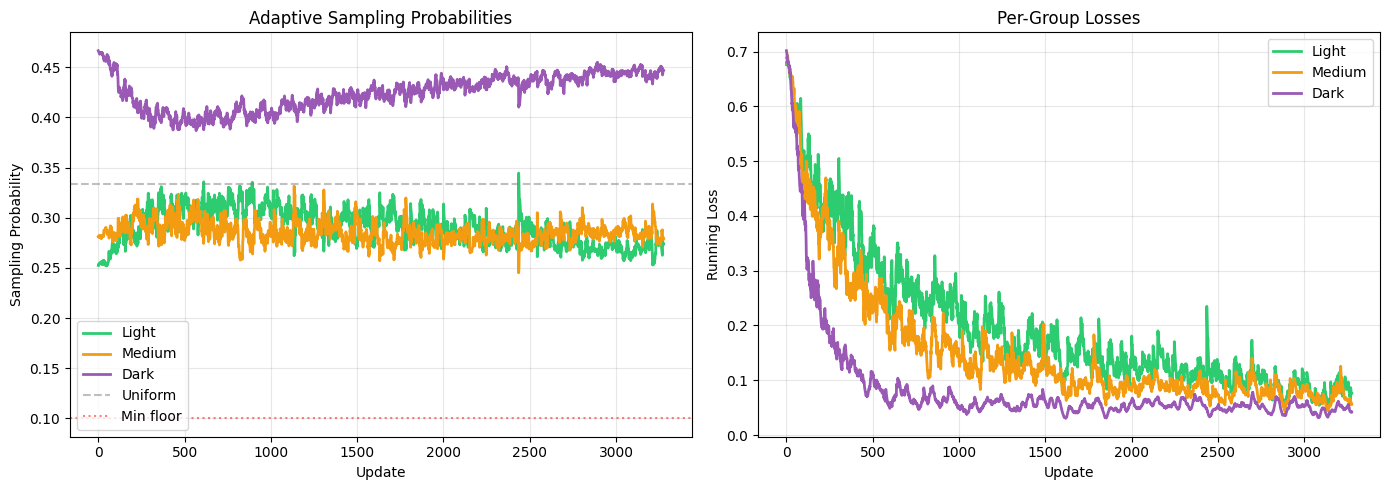

In [14]:
config = get_proposed_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'proposed_seed{SEED}'] = results

save_experiment_results(results, f'proposed_seed{SEED}', RESULTS_DIR)

# Plot adaptive sampler history
if results['adaptive_sampler']:
    results['adaptive_sampler'].plot_history(
        save_path=os.path.join(RESULTS_DIR, f'proposed_seed{SEED}', 'sampler_history.png')
    )

## 4. Training Complete

Seed 123 experiments complete. Now aggregate with seed 42 results.

In [15]:
print("=" * 60)
print(f"SEED {SEED} TRAINING COMPLETE")
print("=" * 60)
print(f"\nModels saved to: {RESULTS_DIR}")
print(f"\nTrained models:")
for name in all_results.keys():
    print(f"  - {name}")

SEED 123 TRAINING COMPLETE

Models saved to: /content/drive/MyDrive/thesis/results

Trained models:
  - baseline_seed123
  - mixup_seed123
  - reweighted_seed123
  - focalloss_seed123
  - proposed_seed123


## 5. Aggregate Results from Both Seeds

Load results from both seed=42 and seed=123, compute mean ± std.

In [16]:
import json
from pathlib import Path

# Models to aggregate
MODELS = ['baseline', 'mixup', 'reweighted', 'focalloss', 'proposed']
SEEDS = [42, 123]

def load_metrics(model_name, seed):
    """Load metrics.json for a specific model and seed."""
    metrics_path = Path(RESULTS_DIR) / f"{model_name}_seed{seed}" / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, 'r') as f:
            return json.load(f)
    else:
        print(f"Warning: {metrics_path} not found")
        return None

# Collect all metrics
all_metrics = {}
for model in MODELS:
    all_metrics[model] = {}
    for seed in SEEDS:
        metrics = load_metrics(model, seed)
        if metrics:
            all_metrics[model][seed] = metrics
            print(f"Loaded {model}_seed{seed}")
        else:
            print(f"Missing {model}_seed{seed}")

Loaded baseline_seed42
Loaded baseline_seed123
Loaded mixup_seed42
Loaded mixup_seed123
Loaded reweighted_seed42
Loaded reweighted_seed123
Loaded focalloss_seed42
Loaded focalloss_seed123
Loaded proposed_seed42
Loaded proposed_seed123


In [17]:
def aggregate_metrics(model_metrics):
    """Compute mean and std for a model across seeds."""
    seeds_data = list(model_metrics.values())
    if len(seeds_data) < 2:
        # Only one seed available
        return seeds_data[0] if seeds_data else None

    # Extract key metrics
    result = {
        'overall': {},
        'fairness': {}
    }

    # Overall metrics
    for key in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']:
        values = [s['overall'].get(key) for s in seeds_data if s['overall'].get(key) is not None]
        if values:
            result['overall'][key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Fairness metrics
    for key in ['equal_opportunity_gap', 'equalized_odds_gap', 'f1_gap']:
        values = [s['fairness'].get(key) for s in seeds_data if s['fairness'].get(key) is not None]
        if values:
            result['fairness'][key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Per-group TPR
    result['fairness']['tpr_per_group'] = {}
    for group in ['Light', 'Medium', 'Dark']:
        values = [s['fairness']['tpr_per_group'].get(group) for s in seeds_data
                  if s['fairness']['tpr_per_group'].get(group) is not None]
        if values:
            result['fairness']['tpr_per_group'][group] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    return result

# Aggregate all models
aggregated = {}
for model in MODELS:
    if all_metrics[model]:
        aggregated[model] = aggregate_metrics(all_metrics[model])

print("\nAggregation complete!")


Aggregation complete!


In [18]:
# Display aggregated results
print("=" * 70)
print("AGGREGATED RESULTS (Mean ± Std over 2 seeds)")
print("=" * 70)

# Build comparison table
rows = []
for model in MODELS:
    if model in aggregated:
        m = aggregated[model]
        row = {
            'Model': model.capitalize(),
            'Balanced Acc': f"{m['overall']['balanced_accuracy']['mean']:.4f} ± {m['overall']['balanced_accuracy']['std']:.4f}",
            'ROC-AUC': f"{m['overall']['roc_auc']['mean']:.4f} ± {m['overall']['roc_auc']['std']:.4f}" if 'roc_auc' in m['overall'] else 'N/A',
            'EO Gap': f"{m['fairness']['equal_opportunity_gap']['mean']:.4f} ± {m['fairness']['equal_opportunity_gap']['std']:.4f}",
            'TPR Dark': f"{m['fairness']['tpr_per_group']['Dark']['mean']:.4f} ± {m['fairness']['tpr_per_group']['Dark']['std']:.4f}",
        }
        rows.append(row)

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

AGGREGATED RESULTS (Mean ± Std over 2 seeds)
     Model    Balanced Acc         ROC-AUC          EO Gap        TPR Dark
  Baseline 0.8272 ± 0.0094 0.9098 ± 0.0102 0.0918 ± 0.0049 0.7073 ± 0.0244
     Mixup 0.8561 ± 0.0095 0.9250 ± 0.0068 0.1005 ± 0.0089 0.7439 ± 0.0122
Reweighted 0.8261 ± 0.0072 0.9099 ± 0.0099 0.0835 ± 0.0007 0.7073 ± 0.0244
 Focalloss 0.8266 ± 0.0078 0.9066 ± 0.0095 0.0846 ± 0.0038 0.7195 ± 0.0122
  Proposed 0.8627 ± 0.0050 0.9302 ± 0.0039 0.0714 ± 0.0025 0.7805 ± 0.0000


In [19]:
# Save aggregated results
aggregated_path = Path(RESULTS_DIR) / 'aggregated_results_2seeds.json'

# Convert numpy types to Python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    return obj

with open(aggregated_path, 'w') as f:
    json.dump(convert_to_serializable(aggregated), f, indent=2)

print(f"\nAggregated results saved to: {aggregated_path}")


Aggregated results saved to: /content/drive/MyDrive/thesis/results/aggregated_results_2seeds.json


In [20]:
# Save comparison table as CSV
comparison_path = Path(RESULTS_DIR) / 'multi_seed_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison table saved to: {comparison_path}")

Comparison table saved to: /content/drive/MyDrive/thesis/results/multi_seed_comparison.csv
